# Real-Time Quantification Strategy for Full-Spectrum Signals

## Overview

After evaluating spectral overlap and recording stability in the dual-color measurement setup, the next step was to define how fluorescence signals would be quantified from the spectrometer output. Because the system preserved full emission spectra in real time, signal extraction did not need to rely on a single wavelength point.

Instead, predefined wavelength ranges were used as the basis for quantification. That strategy allowed the workflow to generate stable analysis-ready fluorescence signals while retaining more spectral information than point-based extraction.

## Defining Wavelength Ranges for Signal Quantification

The measured spectra showed that the green and red sensors formed distinct emission peaks in different wavelength regions. Based on those profiles, 517 nm and 590 nm were selected as the representative center wavelengths for the green and red signals, respectively.

Signal quantification was then defined not from a single wavelength point, but from a predefined ±5 nm range around each center wavelength. Integrating intensity across each wavelength band reduced the influence of local peak fluctuation and frame-to-frame noise while preserving a stable basis for real-time signal extraction.

The following plot shows the wavelength ranges used for signal quantification from the spectrometer output.

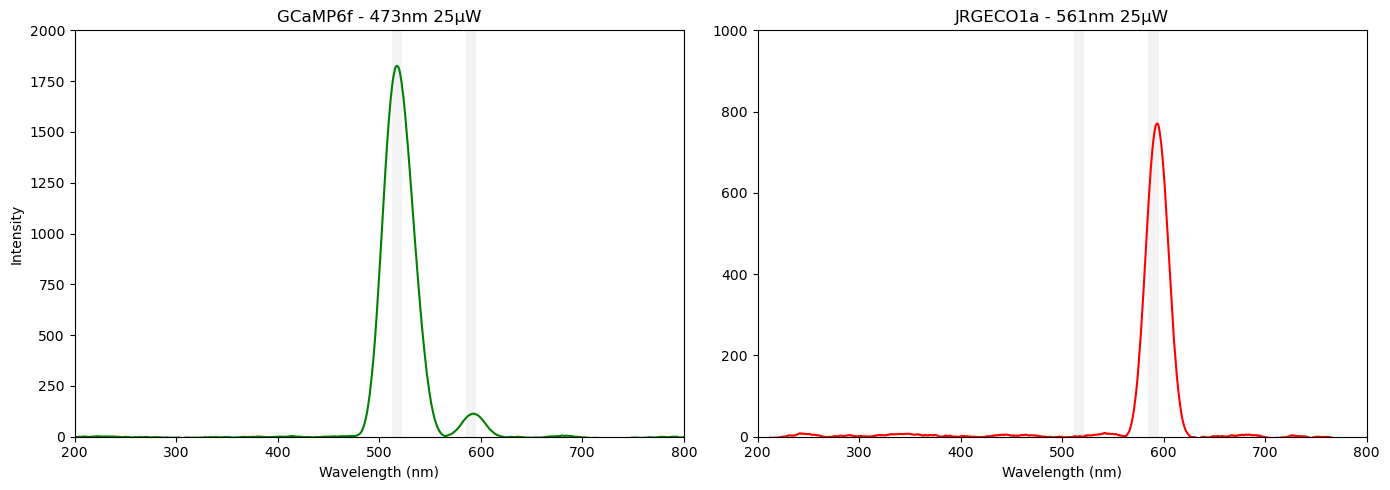

In [7]:


import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Rectangle

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
BASELINE_DIR = PROJECT_ROOT / "data" / "baseline"
GREEN_BASELINE_DIR = BASELINE_DIR / "GCaMP"
RED_BASELINE_DIR = BASELINE_DIR / "jRGECO"

# Define repository-relative paths for representative single-sensor baseline spectra.
gca_green_file = GREEN_BASELINE_DIR / "NoRef_Flna14_g25uw.txt"
jr_red_file    = RED_BASELINE_DIR / "NoRef_Flna18_r25uw.txt"

gca_green = np.loadtxt(gca_green_file)
jr_red    = np.loadtxt(jr_red_file)

gca_x, gca_y = gca_green[:, 0], gca_green[:, 1]
jr_x,  jr_y  = jr_red[:, 0],    jr_red[:, 1]


def band_rectangles(ax, bands, facecolor="lightgray", alpha=0.25):
    """
    bands: list of tuples -> [(center_nm, half_width_nm), ...]
    """
    y0, y1 = ax.get_ylim()
    height = y1 - y0

    for center, half_w in bands:
        x0 = center - half_w
        width = 2 * half_w

        rect = Rectangle(
            (x0, y0), width, height,
            facecolor=facecolor, edgecolor="none", alpha=alpha, zorder=0
        )
        ax.add_patch(rect)

# Define the wavelength bands used for range-based signal quantification
bands = [
    (517, 5),
    (590, 5),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (Left) GCA - Green only
axes[0].plot(gca_x, gca_y, color="green", zorder=2)
axes[0].set_title("GCaMP6f - 473nm 25µW")
axes[0].set_xlim(200, 800)
axes[0].set_ylim(0, 2000)
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Intensity")

band_rectangles(axes[0], bands)

# (Right) JR - Red only
axes[1].plot(jr_x, jr_y, color="red", zorder=2)
axes[1].set_title("JRGECO1a - 561nm 25µW")
axes[1].set_xlim(200, 800)
axes[1].set_ylim(0, 1000)
axes[1].set_xlabel("Wavelength (nm)")

band_rectangles(axes[1], bands)

plt.tight_layout()
plt.show()


**Figure 1. Wavelength bands used for range-based signal quantification from the full-spectrum recordings.**  
Representative single-sensor baseline spectra were plotted for the green and red channels, and the predefined quantification windows centered at 517 nm and 590 nm were highlighted as ±5 nm ranges. This figure shows how signal extraction was defined from wavelength bands rather than from single-point peak values, establishing the basis for stable real-time fluorescence quantification.

## From Spectral Frames to Time-Series Signals

Once the wavelength ranges were defined, integrated intensity values from those ranges could be calculated for every incoming spectral frame. This step linked full-spectrum measurements to continuous green- and red-channel fluorescence signals by converting frame-wise spectral changes into time-series values.

The example below first shows how reward and unreward conditions differ within representative spectral frames at specific time points. Those spectral differences illustrate how signal changes appear within the predefined wavelength ranges. When the same range-based quantification is applied continuously across successive frames, the result becomes a time-series fluorescence signal that can later be aligned to behavioral events and averaged across trials.

### Spectral Illustration of Reward-Related Signal Change

Before validating the final event-aligned traces, representative spectra were compared at selected time points to show how reward and unreward conditions differed within the predefined wavelength ranges. This step was included to connect the wavelength-band definition directly to observable spectral changes before those changes were accumulated into continuous time-series signals.

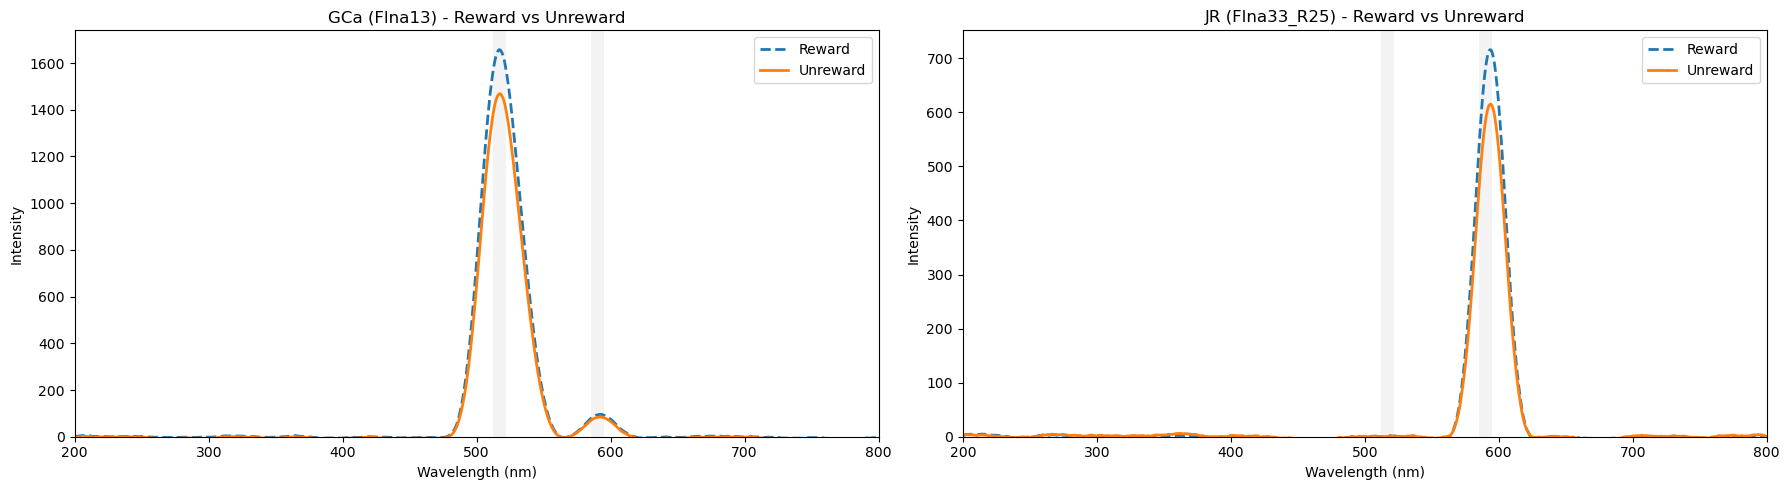

In [8]:
# Load representative reward and unreward spectral frames to illustrate
# how predefined wavelength ranges are converted into interpretable time-series signals.
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Rectangle

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
REWARD_DIR = PROJECT_ROOT / "data" / "reward_unreward"
GREEN_REWARD_DIR = REWARD_DIR / "GCaMP"
RED_REWARD_DIR = REWARD_DIR / "jRGECO"

gca_reward_file   = GREEN_REWARD_DIR / "Flna13_RewardValues.txt"
gca_unreward_file = GREEN_REWARD_DIR / "Flna13_UnrewardValues.txt"

jr_reward_file    = RED_REWARD_DIR / "Flna33_R25_RewardValues.txt"
jr_unreward_file  = RED_REWARD_DIR / "Flna33_R25_UnrewardValues.txt"

gca_reward   = np.loadtxt(gca_reward_file)
gca_unreward = np.loadtxt(gca_unreward_file)

jr_reward    = np.loadtxt(jr_reward_file)
jr_unreward  = np.loadtxt(jr_unreward_file)

# Extract wavelength and intensity arrays from representative reward
# and unreward spectral frames for both channels.
g_rw_x, g_rw_y = gca_reward[:, 0], gca_reward[:, 1]
g_ur_x, g_ur_y = gca_unreward[:, 0], gca_unreward[:, 1]

j_rw_x, j_rw_y = jr_reward[:, 0], jr_reward[:, 1]
j_ur_x, j_ur_y = jr_unreward[:, 0], jr_unreward[:, 1]


def band_rectangles(ax, bands, facecolor="lightgray", alpha=0.25):
    """
    bands: list of tuples -> [(center_nm, half_width_nm), ...]
    """
    y0, y1 = ax.get_ylim()
    height = y1 - y0

    for center, half_w in bands:
        x0 = center - half_w
        width = 2 * half_w

        rect = Rectangle(
            (x0, y0), width, height,
            facecolor=facecolor, edgecolor="none", alpha=alpha, zorder=0
        )
        ax.add_patch(rect)

# Define the wavelength bands used for range-based signal quantification in the green and red channels.
bands = [
    (517, 5),
    (590, 5),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

LW = 2

# Left panel: reward and unreward spectra in the green channel
axes[0].plot(g_rw_x, g_rw_y, linestyle="--", linewidth=LW, label="Reward")
axes[0].plot(g_ur_x, g_ur_y, linestyle="-",  linewidth=LW, label="Unreward")
axes[0].set_title("GCa (Flna13) - Reward vs Unreward")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Intensity")
axes[0].set_xlim(200, 800)
axes[0].set_ylim(0, max(g_rw_y.max(), g_ur_y.max()) * 1.05)
axes[0].legend()

band_rectangles(axes[0], bands)

# Right panel: reward and unreward spectra in the red channel
axes[1].plot(j_rw_x, j_rw_y, linestyle="--", linewidth=LW, label="Reward")
axes[1].plot(j_ur_x, j_ur_y, linestyle="-",  linewidth=LW, label="Unreward")
axes[1].set_title("JR (Flna33_R25) - Reward vs Unreward")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Intensity")
axes[1].set_xlim(200, 800)
axes[1].set_ylim(0, max(j_rw_y.max(), j_ur_y.max()) * 1.05)
axes[1].legend()

band_rectangles(axes[1], bands)

plt.tight_layout()
plt.show()

**Figure 2. Spectral illustration of reward- and unreward-related signal differences within the predefined quantification ranges.**  
Representative spectra at selected time points were compared to show how reward and unreward conditions differed within the wavelength bands used for signal extraction. This figure provides a frame-level example of the spectral changes that are later integrated continuously across time to generate event-aligned fluorescence traces.

## Validation in the Event-Aligned Dataset

After generating real-time time-series signals from frame-wise integrated spectral values, the next step was to confirm that the same signal representation remained usable in the event-aligned dataset used for downstream analysis. The validation code below reconstructs reward-aligned fluorescence traces from the processed dataset and verifies that the range-based quantification remains interpretable after event alignment, baseline subtraction, and trial averaging.

This step was important because the quantification strategy was not intended only for real-time visualization during acquisition. The same signal representation also had to remain consistent in the structured dataset used for later condition comparison and subsequent correction-based analysis.

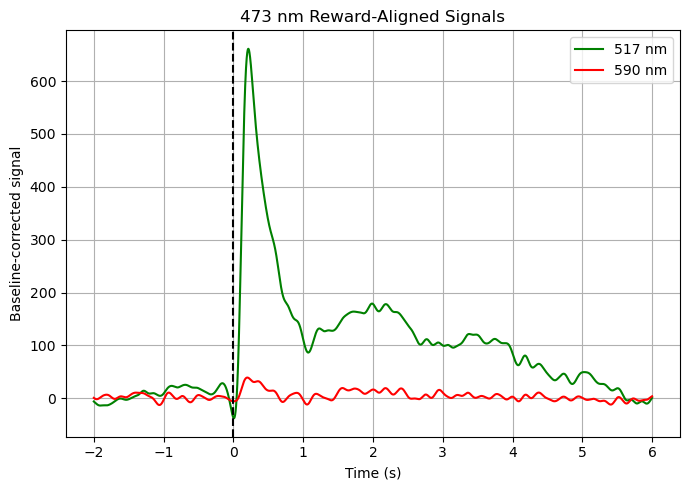

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pathlib import Path


NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample"
STIMULI_FILE = SAMPLE_DIR / "Flna11_473nm_stimuli_python.mat"

# Load a sample processed session dataset for event-aligned validation
def load_stimuli_file():
    if not STIMULI_FILE.exists():
        raise FileNotFoundError(f"Sample dataset not found: {STIMULI_FILE}")

    data = loadmat(STIMULI_FILE)

    # Extract fluorescence signals, reward timestamps, and sampling rate
    photo1 = data['photo1'].flatten()
    photo2 = data['photo2'].flatten()
    sol1times = data['sol1times'].flatten()
    rate = int(data['downsamplingrate'][0][0])

    return photo1, photo2, sol1times, rate


# Reconstruct reward-aligned segments from the processed time-series signals
def compute_reward_aligned(photo1, photo2, sol1times, rate):
    # Use a reward-aligned segment from -2 to +6 s while computing the baseline
    # from the predefined -3 to -2 s interval in the original session trace.
    pre, post = 2, 6

    seg1_list = []
    seg2_list = []

    for t in sol1times:
        idx = int(t * rate)

        start = idx - int(pre * rate)
        end   = idx + int(post * rate)

        base_start = idx - int(3 * rate)
        base_end   = idx - int(2 * rate)

        if start >= 0 and end < len(photo1) and base_start >= 0 and base_end < len(photo1):
            b1 = np.mean(photo1[base_start:base_end])
            b2 = np.mean(photo2[base_start:base_end])

            seg1_list.append(photo1[start:end] - b1)
            seg2_list.append(photo2[start:end] - b2)

    seg1 = np.array(seg1_list)
    seg2 = np.array(seg2_list)
    tvec = np.linspace(-pre, post, seg1.shape[1])

    return seg1, seg2, tvec


# Apply the same range-based quantification output to verify consistency
# after event alignment and trial averaging.
photo1, photo2, sol1times, rate = load_stimuli_file()
p1, p2, t = compute_reward_aligned(photo1, photo2, sol1times, rate)

plt.figure(figsize=(7, 5))
plt.plot(t, p1.mean(axis=0), color='green', label='517 nm')
plt.plot(t, p2.mean(axis=0), color='red', label='590 nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('473 nm Reward-Aligned Signals')
plt.xlabel('Time (s)')
plt.ylabel('Baseline-corrected signal')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

**Figure 3. Event-aligned time-series signals generated from continuous range-based quantification.**  
Fluorescence signals were reconstructed by continuously integrating intensity within the predefined wavelength bands across successive spectral frames. The resulting time-series signals were then aligned to reward events, baseline-subtracted, and averaged across trials. This figure shows the downstream time-domain representation of the spectral changes illustrated at selected time points in the previous panel.

## Outcome

This quantification strategy translated full-spectrum spectrometer output into analysis-ready fluorescence signals without discarding spectral information.  
Signal extraction, quantification, event alignment, and storage were not treated as separate post hoc steps, but were integrated into the real-time measurement workflow itself.

This range-based signal representation established the quantitative foundation for the following analyses, including condition-level comparisons and later validation of signal correction under dual-color recording conditions.